# Lecture 8: Evaluation and Interpretability



:::{admonition} Learning Objectives
:class: tip
After this lecture, you will be able to:
- Evaluate models using appropriate metrics beyond accuracy (RMSE, MAE, R²)
- Apply cross-validation strategies for robust performance estimation
- Interpret model predictions using permutation importance, PDP, and SHAP
- Distinguish between global and local interpretability methods
- Explain the theoretical foundations of Shapley values
- Use Explainable Boosting Machines as inherently interpretable alternatives
- Discuss algorithmic fairness metrics and the incompatibility theorem
- Frame interpretability requirements under the EU AI Act
:::

:::{admonition} Where this lecture sits
:class: note
This lecture builds directly on the modelling workflow from [Lecture 7](lecture_7.ipynb) — we assume you already have a trained model and now need to *understand* it. Post-deployment concerns (monitoring, data and concept drift) are covered separately in [Lecture 9](lecture_9.ipynb). The reference textbook for this material is {cite:t}`molnar2020interpretable`.
:::

## Table of Contents

- [Introduction](#introduction)- [Importance of Interpretability](#importance-of-interpretability)- [Taxonomy of Interpretation Methods](#taxonomy-of-interpretation-methods)- [Python Libraries for Interpretability](#python-libraries-for-interpretability)- [Setup](#setup)- [Global Model-Agnostic Methods](#global-model-agnostic-methods)   - Partial Dependence Plots (PDP)
   - Accumulated Local Effects (ALE) Plots
   - Feature Interaction: H²-Statistic
- [Local Model-Agnostic Methods](#local-model-agnostic-methods)   - Individual Conditional Expectation (ICE)
   - Shapley Values (SHAP)
- [Explainable Boosting Machine (EBM)](#explainable-boosting-machine-ebm)- [Fairness](#fairness)- [Exercises](#exercises)

## Introduction
Machine learning models are increasingly deployed in critical applications where understanding *why* a model makes a particular prediction is as important as the prediction itself. This lecture covers methods for interpreting and explaining machine learning models, enabling you to debug models, improve features, detect bias, and meet regulatory requirements.

```{note}
This lecture focuses on **interpretability** rather than just **evaluation metrics**. We're not just asking "how accurate is the model?" but "why did the model make this prediction?"
```


### Evaluation metrics
Before we can interpret a model we need a common vocabulary for its *performance*. This subsection collects the metrics used throughout the lecture. A comprehensive treatment is in {cite:t}`hastie2009elements`.

Let $y_i$ denote the true target for observation $i$, $\hat{y}_i$ the model prediction, $\bar{y}$ the sample mean, and $n$ the number of observations.

#### Regression metrics

**Root Mean Squared Error (RMSE).** Penalises large errors quadratically and preserves the unit of $y$:

$$
\mathrm{RMSE} \;=\; \sqrt{\frac{1}{n}\sum_{i=1}^{n}\bigl(y_i - \hat{y}_i\bigr)^2}.
$$

**Mean Absolute Error (MAE).** Robust to outliers and equal-weighted per observation:

$$
\mathrm{MAE} \;=\; \frac{1}{n}\sum_{i=1}^{n}\bigl|\,y_i - \hat{y}_i\,\bigr|.
$$

**Coefficient of determination ($R^2$).** The fraction of variance in $y$ explained by the model:

$$
R^2 \;=\; 1 \;-\; \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}.
$$

$R^2 = 1$ is a perfect fit, $R^2 = 0$ matches the constant mean predictor, and negative values indicate a model *worse* than the mean.

**Mean Absolute Percentage Error (MAPE).** Scale-free, but undefined when $y_i = 0$ and asymmetric in relative errors:

$$
\mathrm{MAPE} \;=\; \frac{100}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat{y}_i}{y_i}\right|.
$$

**Deviance.** The generalisation of squared error to non-Gaussian likelihoods (Poisson, Gamma, Tweedie). For a saturated log-likelihood $\ell_{\mathrm{sat}}$ and fitted log-likelihood $\ell(\hat{y})$:

$$
D \;=\; 2\bigl(\ell_{\mathrm{sat}} - \ell(\hat{y})\bigr).
$$

Deviance reduces to $\mathrm{SSE}$ under a Gaussian likelihood and is the natural loss for GLMs.

#### Classification metrics

Let $\mathrm{TP}, \mathrm{FP}, \mathrm{TN}, \mathrm{FN}$ denote true positives, false positives, true negatives and false negatives.

- **Accuracy**: $\;(\mathrm{TP} + \mathrm{TN}) \,/\, n$.
- **Precision**: $\;\mathrm{TP} \,/\, (\mathrm{TP} + \mathrm{FP})$ — of predicted positives, how many are correct.
- **Recall (sensitivity, TPR)**: $\;\mathrm{TP} \,/\, (\mathrm{TP} + \mathrm{FN})$ — of true positives, how many were retrieved.
- **F1**: harmonic mean of precision and recall,
  $F_1 = 2 \cdot \tfrac{\mathrm{precision}\cdot\mathrm{recall}}{\mathrm{precision}+\mathrm{recall}}$.
- **ROC-AUC**: area under the ROC curve, i.e. the probability that a random positive receives a higher score than a random negative:
  $\mathrm{AUC} = \Pr\bigl(\hat{s}(X^+) > \hat{s}(X^-)\bigr)$.

:::{note}
No single scalar summarises a model. Always report at least one *scale-preserving* metric (RMSE / MAE) alongside one *scale-free* one ($R^2$ / MAPE), and inspect the residual distribution rather than the mean alone.
:::

## Importance of Interpretability

### Why Interpretability Matters

Making models interpretable and accessible for developers, data scientists, and business stakeholders helps with multiple critical objectives (according to InterpretML):

**Model Debugging**  
*Why did my model make this mistake?*

When a model fails, we need to understand what went wrong. Was it a data quality issue? Did the model learn a spurious correlation? Is there a bug in feature engineering?

**Feature Engineering**  
*How can I improve my model?*

Understanding which features drive predictions helps identify opportunities for creating better features or removing noisy ones.

**Detecting Fairness Issues**  
*Does my model discriminate?*

Models can learn and amplify biases present in training data. Interpretability tools help identify when models make decisions based on protected attributes or their proxies.

**Human-AI Cooperation**  
*How can I understand and trust the model's decisions?*

For models to be useful in practice, humans need to trust them. This requires understanding how the model works and when it might be unreliable.

**Regulatory Compliance**  
*Does my model satisfy legal requirements?*

Regulations like GDPR's "right to explanation" or fair lending laws require organizations to explain automated decisions.

**High-Risk Applications**  
Applications in healthcare, finance, and judicial systems require interpretable models because the stakes are too high for black-box predictions.

```{warning}
In high-stakes domains like healthcare or criminal justice, using a black-box model without interpretability tools can be **unethical and potentially illegal**, regardless of R².
```


### Real-World Example: Credit Scoring

Imagine a bank uses a machine learning model to approve loans. An applicant is denied and asks why. The bank must be able to explain:

- Which factors led to the denial?
- Would changing certain factors (income, debt-to-income ratio) lead to approval?
- Is the model treating similar applicants consistently?
- Are there signs of discriminatory patterns?

Without interpretability, none of these questions can be answered.


### Constraints on Interpretability

Similar to modeling constraints (computational budget, latency requirements), we might face **implicit constraints on interpretability**. These could arise from:

**Technical Stack**  
Your production environment might only support certain model types (e.g., parametric models with coefficients).

**User Needs**  
Business users might require models they can edit manually (e.g., adjusting risk scores based on domain knowledge).

**Regulatory Requirements**  
Some industries require fully transparent models (e.g., linear models in some insurance contexts).

**Deployment Environment**  
Edge devices or low-latency systems might not support complex explanation methods.

**Organizational Culture**  
Some organizations have strong preferences for interpretable models based on past experiences or risk tolerance.

```{hint}
Always clarify interpretability requirements **before** model development. It's much harder to add interpretability after choosing a complex black-box model.
```


#### Example Scenario

```text
Constraint: "The model must be editable by domain experts"

This eliminates:
- Neural networks
- Random forests
- XGBoost

This suggests:
- Linear models
- Explainable Boosting Machines (EBM)
- Rule-based systems
```


## Taxonomy of Interpretation Methods
Understanding the landscape of interpretation methods helps you choose the right tool for your needs.


### Intrinsic vs. Post-Hoc Interpretability

**Intrinsically Interpretable Models**  
Models that are interpretable by design due to their simple structure:

- Linear regression
- Logistic regression
- Decision trees (shallow)
- Rule-based systems
- Generalized Additive Models (GAMs)

**Post-Hoc Interpretation**  
Methods applied after training to explain complex models:

- Partial Dependence Plots
- SHAP values
- Feature importance
- LIME (Local Interpretable Model-agnostic Explanations) {cite}`ribeiro2016lime`

```{note}
There's often a trade-off: intrinsically interpretable models are simpler but may have lower predictive performance, while complex models with post-hoc explanations may perform better but are harder to fully trust. See {cite:t}`molnar2020interpretable` for a book-length treatment.
```


### Model-Specific vs. Model-Agnostic

**Model-Specific Methods**  
Limited to a particular target of models:

- Coefficients in linear models
- Feature importance in tree-based models
- Attention weights in neural networks

**Model-Agnostic Methods**  
Can be applied to any model producing predictions from features:

- Partial Dependence Plots (PDP)
- Accumulated Local Effects (ALE)
- SHAP values
- Permutation feature importance

```{tip}
When possible, use model-agnostic methods. They allow you to compare interpretations across different model types and are more flexible when you need to change models.
```


### Local vs. Global Interpretability

**Global Methods**  
Explain the general behavior of the model across all predictions:

- Overall feature importance
- Average feature effects
- Model-wide interaction patterns

*Question:* "What features matter most for this model overall?"

**Local Methods**  
Explain individual predictions:

- Individual feature contributions
- Counterfactual explanations
- Local surrogate models

*Question:* "Why did the model predict this specific value for this instance?"

#### Comparison Table

| Dimension | Global | Local |
|---|---|---|
| Scope | Entire model | Single prediction |
| Use Case | Feature engineering, fairness audits | Individual decision explanation |
| Examples | PDP, ALE, overall SHAP | ICE, local SHAP, LIME |
| Output | Average patterns | Instance-specific decomposition |


## Python Libraries for Interpretability
Several excellent libraries exist for model interpretability. Each has strengths for different use cases.


### Overview of Major Libraries


#### DALEX
*moDel Agnostic Language for Exploration and eXplanation*

**Strengths:**
- Beautiful visualizations
- Comprehensive suite of methods
- Good documentation
- Works with many model types


#### InterpretML
State-of-the-art interpretability including Explainable Boosting Machines {cite}`nori2019interpretml`.

**Strengths:**
- Includes EBM (best of interpretability + performance)
- Microsoft-backed project
- Interactive visualizations
- Both glass-box and black-box methods


#### scikit-learn
Basic interpretability tools built into sklearn.

**Strengths:**
- No extra dependencies
- Well-integrated with sklearn workflow
- Efficient implementations


#### SHAP
Game-theoretic approach to explaining predictions.

**Strengths:**
- Theoretically grounded (Shapley values)
- Excellent visualizations
- Optimized for tree models
- Wide adoption in industry


## Setup
We'll prepare datasets and baseline models used in the runnable examples below.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from fun_ds.plotting import set_lecture_style

set_lecture_style()

np.random.seed(42)

# California Housing (regression)
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name="MedHouseVal")

# Subsample for speed (optional)
if len(X) > 12000:
    idx = np.random.choice(len(X), size=12000, replace=False)
    X = X.iloc[idx].reset_index(drop=True)
    y = y.iloc[idx].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100, random_state=42, n_jobs=-1, min_samples_leaf=2
)
model.fit(X_train, y_train)

print("RandomForestRegressor R^2 train:", model.score(X_train, y_train))
print("RandomForestRegressor R^2 test :", model.score(X_test, y_test))

RandomForestRegressor R^2 train: 0.954661055399073
RandomForestRegressor R^2 test : 0.8015098705401437


In [2]:
# Helper utilities: make sklearn inspection robust across versions
import numpy as np
import pandas as pd


def feature_index(X: pd.DataFrame, feature):
    """Return the integer column index for a feature name or pass-through for integer indices."""
    if isinstance(feature, int | np.integer):
        return int(feature)
    if isinstance(feature, str):
        if feature not in X.columns:
            raise KeyError(
                f"Feature '{feature}' not found. Available columns: {list(X.columns)}"
            )
        return int(X.columns.get_loc(feature))
    raise TypeError(f"Unsupported feature spec: {type(feature)}")


def feature_pair_indices(X: pd.DataFrame, pair):
    a, b = pair
    return (feature_index(X, a), feature_index(X, b))

### DALEX quick demo (optional)


```{hint}
DALEX's unified interface makes it easy to compare multiple models. Create explainers for different models and compare their interpretations side-by-side.
```


## Global Model-Agnostic Methods
Global methods describe the average behavior of a machine learning model across all predictions. These methods are often expressed as **expected values based on the distribution of the data**.

We will cover:

- **Partial Dependence Plots (PDP)**: Average feature effect marginalizing over other features
- **Accumulated Local Effects (ALE)**: Corrects feature effect for feature dependence
- **Feature Interaction (H²-statistic)**: Quantifies joint effects of features


### Partial Dependence Plots (PDP)

#### Introduction
Partial dependence plots were introduced by {cite:t}`friedman2001greedy` in the context of Gradient Boosting Machines. They show the **marginal effect** of one (univariate PDP) or two (bivariate PDP) features on the prediction.

#### Mathematical Definition
The partial dependence function for regression is defined as:

$$
\hat{f}_S(x_S) = \mathbb{E}_{X_C}\left[\hat{f}(x_S, X_C)\right] = \int \hat{f}(x_S, x_C) \, dP(X_C)
$$

where:

- $x_S$: feature(s) for which PDP is computed
- $X_C$: all other features (complement set)
- $\hat{f}$: trained model

We **marginalize over all other features** and get a function that only depends on the feature(s) $S$ we're interested in.

```{note}
The outer expectation is taken over the **marginal** distribution of $X_C$, i.e. $P(X_C)$ — *not* the conditional $P(X_C \mid X_S = x_S)$. This is exactly what makes PDPs biased when $X_S$ and $X_C$ are correlated: we integrate over combinations $(x_S, x_C)$ that may never occur jointly in the data.
```

#### Practical Computation
This translates to computing the **sample mean** for various values of $x_S$, while keeping $X_C$ fixed:

$$
\hat{f}_S(x_S) = \frac{1}{n}\sum_{i=1}^{n} \hat{f}(x_S, x_C^{(i)})
$$

```{warning}
With **correlated features**, PDPs are likely to produce combinations of features that are very unlikely or even impossible (e.g., a 15 m² house with 5 bedrooms). Yet, it gives us the average "mechanical" effect of changes in $x_S$ on predicted outcomes.
```


#### Algorithm: PDP Recipe

1. **Select feature** $x_S$ to visualize
2. **Define grid** for the feature (numeric ranges or categorical values) on the domain of $x_S$
3. **For each grid value**:
   - Replace the feature value with the grid value for all instances
   - Compute predictions for all instances
   - Average the predictions
4. **Plot** average predictions over the grid


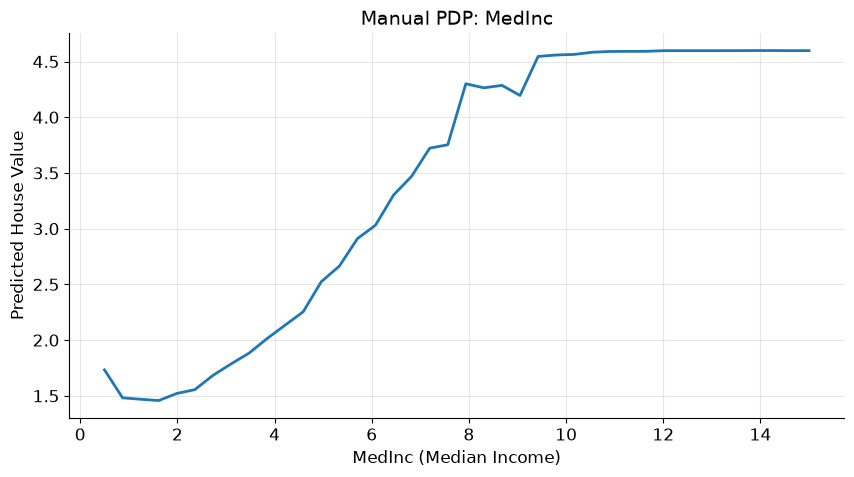

In [3]:
# Manual PDP computation for one feature (MedInc)
def compute_pdp(model, X, feature, grid_resolution=50):
    feature_values = np.linspace(X[feature].min(), X[feature].max(), grid_resolution)
    pdp_values = []
    for value in feature_values:
        X_temp = X.copy()
        X_temp[feature] = value
        preds = model.predict(X_temp)
        pdp_values.append(preds.mean())
    return feature_values, np.array(pdp_values)


grid, pdp_vals = compute_pdp(model, X_test, "MedInc", grid_resolution=40)

plt.figure(figsize=(10, 5))
plt.plot(grid, pdp_vals, linewidth=2)
plt.xlabel("MedInc (Median Income)")
plt.ylabel("Predicted House Value")
plt.title("Manual PDP: MedInc")
plt.grid(True, alpha=0.3)
plt.show()

Expected Output:

```text
A line plot showing:
- X-axis: Median income
- Y-axis: Predicted house price
- Upward trend: Higher income → Higher predicted price
- Possible non-linearity (curved relationship)
```


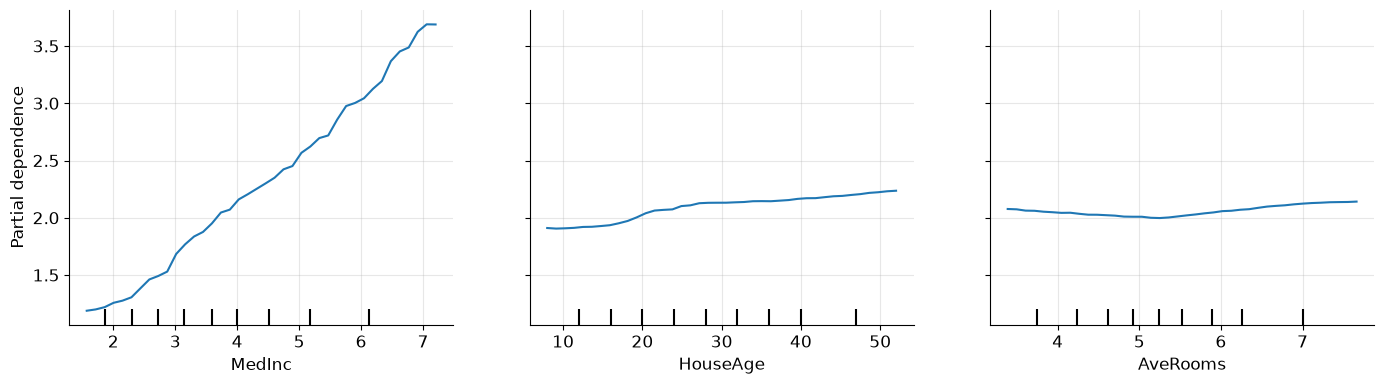

In [4]:
from sklearn.inspection import PartialDependenceDisplay

features = [
    feature_index(X_test, "MedInc"),
    feature_index(X_test, "HouseAge"),
    feature_index(X_test, "AveRooms"),
]
fig, ax = plt.subplots(figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    model, X_test, features, grid_resolution=40, ax=ax
)
plt.tight_layout()
plt.show()

```text
Output: PDPs for:
1. MedInc
2. HouseAge
3. AveRooms
```


In [5]:
# DALEX demo (optional) on California Housing (regression)
try:
    import dalex as dx
except ImportError:
    print("DALEX is not installed. Install with: pip install dalex")
else:
    exp = dx.Explainer(model, X_test, y_test, label="RF Housing")

    # Model performance (prints summary; plotting depends on environment)
    perf = exp.model_performance()
    print(perf)

    # Feature importance
    parts = exp.model_parts()
    print(parts)

    # Partial dependence / model profile (PDP)
    profile = exp.model_profile(type="partial", variables=["MedInc", "AveRooms"])
    print(profile)

    # Optional plotting (often uses plotly)
    # perf.plot()
    # parts.plot()
    # profile.plot()

DALEX is not installed. Install with: pip install dalex


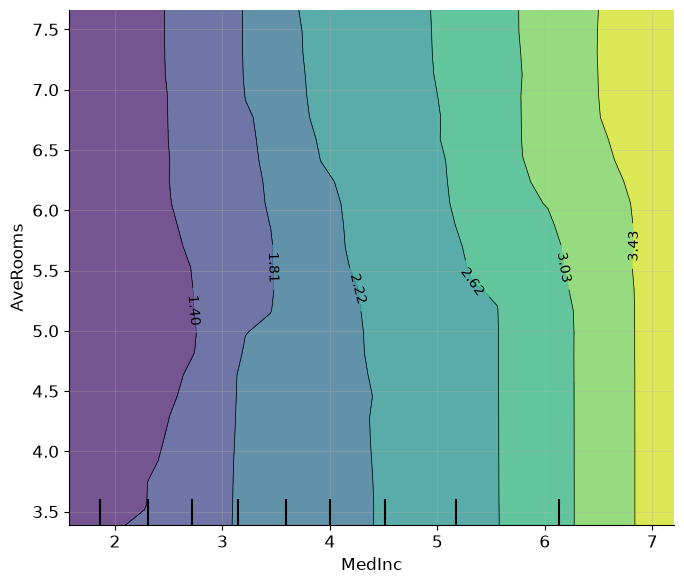

In [6]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(7, 6))
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    [feature_pair_indices(X_test, ("MedInc", "AveRooms"))],
    grid_resolution=25,
    ax=ax,
)
plt.tight_layout()
plt.show()

```text
Output: Heatmap/contour-like visualization showing interaction patterns between features.
```


#### Interpretation Examples

**Monotonic Positive Relationship**

```text
Feature: Years of Education
PDP: Steadily increasing line
Interpretation: Each additional year of education increases predicted salary by ~$X
```

**Non-linear Relationship**

```text
Feature: Age
PDP: Inverted U-shape
Interpretation: Salary increases with age until ~45, then plateaus or slightly decreases
```

**Plateau Effect**

```text
Feature: Credit Score
PDP: Steep increase, then flat
Interpretation: Credit score matters up to 700, above that has minimal additional effect
```


#### Advantages and Disadvantages

**Advantages:**
- ✓ Simple and intuitive way to summarize feature effects
- ✓ Easy to communicate to non-technical stakeholders
- ✓ Works for any supervised learning model
- ✓ Can show non-linear relationships
- ✓ Relatively robust to sampling (for large datasets)

**Disadvantages:**
- ✗ For **correlated features**, PDPs are biased as they assume independence
- ✗ For large datasets, computationally expensive (though robust to sampling)
- ✗ Can be misleading when features interact strongly
- ✗ Averages can hide heterogeneous effects
- ✗ Extrapolation to unlikely feature combinations

```{warning}
**Critical Limitation:** PDPs assume feature independence. If features are correlated, PDPs may show impossible scenarios.
```


#### When to Use PDPs
- ✓ Features are mostly independent
- ✓ Quick, intuitive understanding of feature effects
- ✓ Communication with non-technical stakeholders
- ✓ Initial exploration before more sophisticated methods

#### When to Avoid PDPs
- ✗ Features are highly correlated (use ALE instead)
- ✗ Strong feature interactions (use H²-statistic first)
- ✗ Need local explanations (use ICE or SHAP instead)


### Accumulated Local Effects (ALE) Plots

#### Motivation
Accumulated Local Effects aim to address one key drawback of PDPs by **accounting for correlation between features**. ALE plots were proposed by {cite:t}`apley2020ale`.

**Example: Correlated Features**

```text
House Price Prediction:
- Surface area and number of rooms are positively correlated
- A surface of 15 m² with 5 rooms doesn't make sense
- PDP would still compute predictions for this impossible combination
```


Consider two features:

- **Surface area**: 15–200 m²
- **Number of rooms**: 1–5 rooms

**Realistic combinations:**
- 15 m² → 1 room (studio)
- 100 m² → 3 rooms
- 200 m² → 5 rooms

**Unrealistic (but PDP considers them):**
- 15 m² → 5 rooms
- 200 m² → 1 room


#### Why Not Just Use Conditional Averages?

We could compute **conditional** average predictions. These are known as **M-Plots (Marginal Plots)**, but they measure the **combined effect** of the feature AND its correlates.

**Question:** How can we disentangle the feature effects while still accounting for correlation?

**Answer:** This is what ALE plots achieve!


#### Mathematical Intuition

Instead of computing conditional averages, ALE plots compute **differences in predictions** while conditioning on other features.

Recall PDP:

$$
\hat{f}_{S,PDP}(x_S) = \mathbb{E}_{X_C}\left[\hat{f}(x_S, X_C)\right]
$$

M-plots (conditional):

$$
\hat{f}_{S,M}(x_S) = \mathbb{E}_{X_C\mid X_S=x_S}\left[\hat{f}(x_S, X_C) \mid X_S = x_S\right]
$$

ALE uses **local differences** and accumulation.


#### ALE Method Details

**Step 1: Partition feature range into intervals**

$$
(z_{0,S}, z_{1,S}], (z_{1,S}, z_{2,S}], \ldots, (z_{K-1,S}, z_{K,S}]
$$

**Step 2: Compute local effects**

$$
\Delta_k = \frac{1}{n_k} \sum_{i: x_S^{(i)} \in (z_{k-1,S}, z_{k,S}]}
\left[\hat{f}(z_{k,S}, x_C^{(i)}) - \hat{f}(z_{k-1,S}, x_C^{(i)})\right]
$$

**Step 3: Accumulate effects**

$$
\hat{f}_{S,ALE}(x_S) = \sum_{k=1}^{k_S(x_S)} \Delta_k
$$

**Step 4: Center the plot**

$$
\hat{f}_{S,ALE}(x_S) := \hat{f}_{S,ALE}(x_S) - \frac{1}{n}\sum_{i=1}^{n} \hat{f}_{S,ALE}(x_S^{(i)})
$$

```{note}
**Why center?** The ALE is defined by *accumulating* local differences, so it is only identified **up to an additive constant** — much like an antiderivative. Centering it to have mean zero over the data distribution gives every ALE plot a common, interpretable zero: the value 0 on the y-axis corresponds to the average model prediction, and the curve reads as *deviation from that average* attributable to the feature.
```


In [7]:
# ALE with PyALE (optional)
try:
    from PyALE import ale
except ImportError:
    print("PyALE is not installed. Install with: pip install PyALE")
else:
    ale_eff = ale(X=X_test, model=model, feature=["MedInc"], grid_size=30)
    print(ale_eff.head())
    plt.figure(figsize=(10, 5))
    plt.plot(ale_eff.index, ale_eff.values)
    plt.axhline(0, linestyle="--", alpha=0.5)
    plt.xlabel("MedInc")
    plt.ylabel("ALE Effect on Prediction")
    plt.title("ALE Plot: Median Income")
    plt.grid(True, alpha=0.3)
    plt.show()

PyALE is not installed. Install with: pip install PyALE


In [8]:
# ALE with alepython (optional)
try:
    from alepython import ale_plot
except ImportError:
    print("alepython is not installed. Install with: pip install alepython")
else:
    # First-order ALE
    ale_plot(model, X_train, "MedInc", bins=30)
    # Second-order ALE (interaction)
    ale_plot(model, X_train, ["MedInc", "AveRooms"], bins=15)

alepython is not installed. Install with: pip install alepython


#### ALE vs PDP Comparison

**Scenario: Highly Correlated Features**

Below we generate correlated features and fit a model. (A full PDP-vs-ALE numerical comparison would require an ALE implementation; the code below focuses on data generation and model fitting.)


#### PDP vs ALE: side-by-side comparison (California Housing)

Below we compute a **PDP** and a **first-order ALE** for the same feature (`MedInc`) and plot them together.

```{note}
- The PDP is an *unconditional* marginal effect (can drift into unrealistic regions if features are correlated).
- The ALE estimates *local* changes within bins and then accumulates them (stays closer to the data distribution).
```


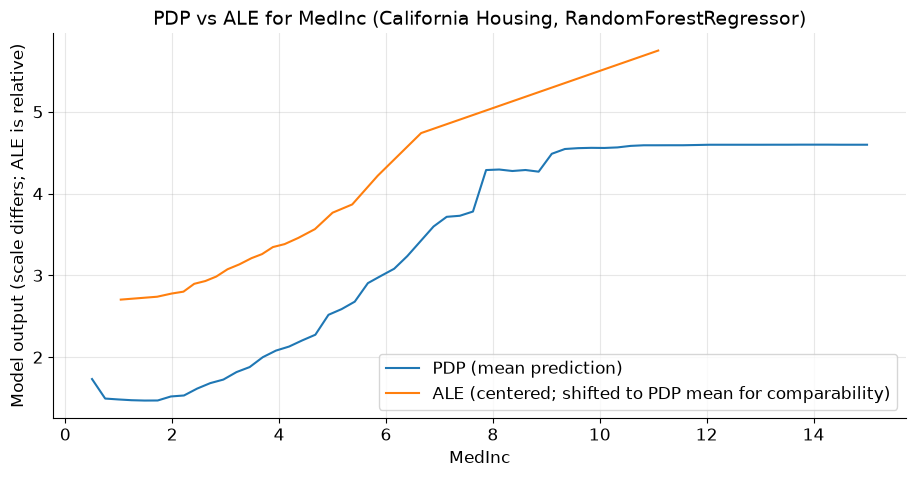

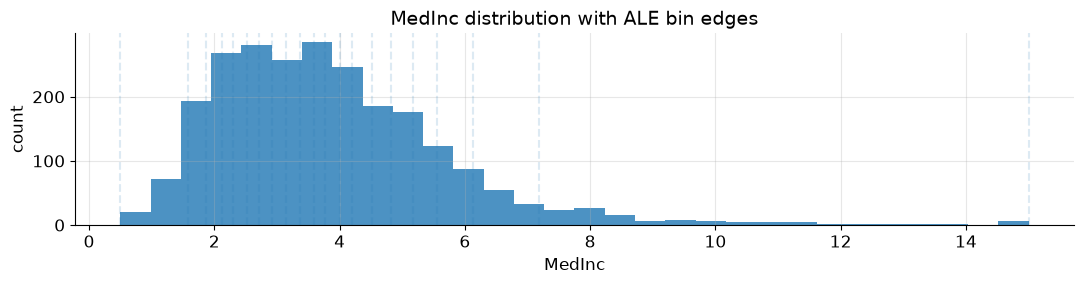

In [9]:
import matplotlib.pyplot as plt
import numpy as np


def compute_pdp_1d(model, X, feature, grid_resolution=50):
    f = feature
    grid = np.linspace(X[f].min(), X[f].max(), grid_resolution)
    pdp = []
    for v in grid:
        X_tmp = X.copy()
        X_tmp[f] = v
        pdp.append(model.predict(X_tmp).mean())
    return grid, np.asarray(pdp)


def compute_ale_1d(model, X, feature, bins=20):
    """Simple first-order ALE for a numeric feature (regression).

    Steps:
    1) bin feature by quantiles (equal-frequency bins)
    2) for each bin, compute average prediction difference f(z_k, x_C) - f(z_{k-1}, x_C)
    3) accumulate and center to mean zero
    """
    x = X[feature].to_numpy()
    # Quantile bin edges (unique to avoid empty bins)
    qs = np.linspace(0, 1, bins + 1)
    edges = np.quantile(x, qs)
    edges = np.unique(edges)
    if len(edges) < 3:
        raise ValueError("Not enough unique values to bin feature for ALE.")
    K = len(edges) - 1

    deltas = np.zeros(K)
    counts = np.zeros(K, dtype=int)

    for k in range(K):
        lo, hi = edges[k], edges[k + 1]
        mask = (x > lo) & (x <= hi) if k > 0 else (x >= lo) & (x <= hi)
        idx = np.where(mask)[0]
        counts[k] = len(idx)
        if len(idx) == 0:
            continue
        X_lo = X.iloc[idx].copy()
        X_hi = X.iloc[idx].copy()
        X_lo[feature] = lo
        X_hi[feature] = hi
        deltas[k] = (model.predict(X_hi) - model.predict(X_lo)).mean()

    ale = np.cumsum(deltas)
    # Use bin midpoints for plotting
    mids = 0.5 * (edges[:-1] + edges[1:])
    # Center ALE so mean effect is 0 over the data distribution (approx by weighting by counts)
    if counts.sum() > 0:
        mean_effect = np.average(ale, weights=counts)
        ale = ale - mean_effect
    return mids, ale, edges


# Compute
grid, pdp = compute_pdp_1d(model, X_test, "MedInc", grid_resolution=60)
mids, ale, edges = compute_ale_1d(model, X_test, "MedInc", bins=20)

# Plot
plt.figure(figsize=(11, 5))
plt.plot(grid, pdp, label="PDP (mean prediction)")
plt.plot(
    mids,
    ale + pdp.mean(),
    label="ALE (centered; shifted to PDP mean for comparability)",
)
plt.xlabel("MedInc")
plt.ylabel("Model output (scale differs; ALE is relative)")
plt.title("PDP vs ALE for MedInc (California Housing, RandomForestRegressor)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Optional: show feature distribution + bin edges
plt.figure(figsize=(11, 3))
plt.hist(X_test["MedInc"], bins=30, alpha=0.8)
for e in edges:
    plt.axvline(e, linestyle="--", alpha=0.15)
plt.title("MedInc distribution with ALE bin edges")
plt.xlabel("MedInc")
plt.ylabel("count")
plt.tight_layout()
plt.show()

In [10]:
# Optional: compare against PyALE implementation if installed
try:
    from PyALE import ale as pyale_ale
except ImportError:
    print("PyALE not installed (optional). Install with: pip install PyALE")
else:
    ale_eff = pyale_ale(X=X_test, model=model, feature=["MedInc"], grid_size=20)
    plt.figure(figsize=(11, 5))
    plt.plot(mids, ale, label="Custom ALE (centered)")
    plt.plot(ale_eff.index, ale_eff.values, label="PyALE (centered)")
    plt.axhline(0, linestyle="--", alpha=0.4)
    plt.xlabel("MedInc")
    plt.ylabel("ALE effect")
    plt.title("ALE comparison: custom vs PyALE")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

PyALE not installed (optional). Install with: pip install PyALE


**Key Differences:**

| Aspect | PDP | ALE |
|---|---|---|
| Feature Correlation | Assumes independence (biased) | Accounts for correlation (unbiased) |
| Interpretation | Average effect | Local accumulated effect |
| Computation | Simpler | More complex |
| Extrapolation | To unlikely combinations | Stays in data distribution |
| Centering | Not centered by default | Centered around zero |


#### Visual Comparison Example

```text
For correlated features x1 and x2:

PDP for x1:
────────────────
Shows combined effect of x1 AND x2 (because they're correlated)
May show stronger effect than x1 actually has

ALE for x1:
────────────────
Shows isolated effect of x1 only
Correctly attributes effects
Stays within realistic data regions
```


#### Advantages and Disadvantages (ALE)

**Advantages:**
- ✓ **Unbiased** for correlated features (main advantage over PDP)
- ✓ Faster to compute for large datasets
- ✓ No extrapolation to unrealistic feature combinations
- ✓ Works for any model type

**Disadvantages:**
- ✗ **Interpretation is more complex** due to conditional difference computation
- ✗ **Sensitive to binning** strategy
- ✗ Less intuitive for non-technical audiences
- ✗ Fewer software implementations available

```{hint}
**Rule of Thumb:** Use ALE when you have correlated features (which is most real-world datasets). Use PDP for quick exploration when features are independent.
```


#### When to Use ALE
- ✓ Features are correlated (most real-world cases)
- ✓ You need unbiased feature effect estimates
- ✓ Working with large datasets
- ✓ Feature interactions are present

#### When to Use PDP
- ✓ Features are mostly independent
- ✓ Quick exploratory analysis
- ✓ Communicating with non-technical stakeholders (easier to explain)


### Feature Interaction: H²-Statistic

#### Introduction
One way to measure **interaction strength** is to measure how much variation of the prediction depends on the **interaction** between features. This is known as the **H²-statistic** by {cite:t}`friedman2008predictive`.

**Intuition:** If two features don't interact, the joint effect should be the sum of individual effects.


#### Mathematical Definition

If two features **do not interact**, we can decompose the bivariate PDP as the sum of univariate PDPs:

$$
PD_{jk}(x_j, x_k) = PD_j(x_j) + PD_k(x_k)
$$

The **H²-statistic** is defined as:

$$
H^2_{jk} = \frac{\sum_{i=1}^{n} \left[PD_{jk}(x_j^{(i)}, x_k^{(i)}) - PD_j(x_j^{(i)}) - PD_k(x_k^{(i)})\right]^2}
{\sum_{i=1}^{n} PD_{jk}^2(x_j^{(i)}, x_k^{(i)})}
$$


#### Interpretation

- $H^2_{jk} \approx 0$: additive effects (no interaction)
- $H^2_{jk} \approx 1$: dominated by interaction
- $0 < H^2_{jk} < 1$: partial interaction

**Example Values:**

```text
H² = 0.05:  Weak interaction
H² = 0.30:  Moderate interaction
H² = 0.70:  Strong interaction
H² = 0.95:  Very strong interaction
```


In [11]:
# Simplified H² statistic implementation (robust to sklearn versions)
import numpy as np
from sklearn.inspection import partial_dependence


def compute_h2_statistic(model, X, feature_j, feature_k, n_grid=20):
    """Compute a simplified H² interaction statistic on the PDP grid.

    Uses integer feature indices internally (robust if sklearn doesn't accept column names).
    """
    j = feature_index(X, feature_j)
    k = feature_index(X, feature_k)

    pdp_jk = partial_dependence(model, X, features=[(j, k)], grid_resolution=n_grid)
    pdp_j = partial_dependence(model, X, features=[j], grid_resolution=n_grid)
    pdp_k = partial_dependence(model, X, features=[k], grid_resolution=n_grid)

    interaction_term = pdp_jk["average"][0] - np.add.outer(
        pdp_j["average"][0], pdp_k["average"][0]
    )
    numerator = np.sum(interaction_term**2)
    denominator = np.sum(pdp_jk["average"][0] ** 2)
    return float(numerator / (denominator + 1e-10))


h2_income_rooms = compute_h2_statistic(model, X_test, "MedInc", "AveRooms", n_grid=15)
print(f"H² statistic (MedInc × AveRooms): {h2_income_rooms:.4f}")

H² statistic (MedInc × AveRooms): 0.7338


#### Practical Interpretation

Compute H² for a small set of features and visualize as a heatmap.


             MedInc  HouseAge  AveRooms  AveBedrms
MedInc          NaN  0.655903  0.723340   0.678973
HouseAge   0.655903       NaN  0.984586   0.953103
AveRooms   0.723340  0.984586       NaN   0.977664
AveBedrms  0.678973  0.953103  0.977664        NaN


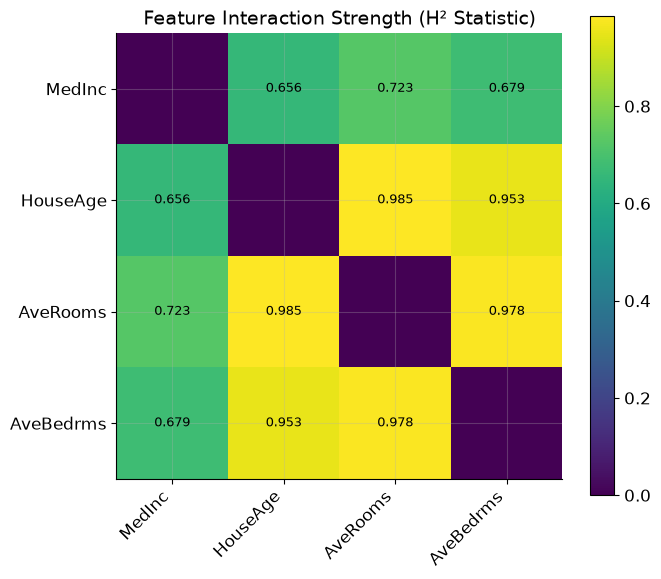

In [12]:
features = ["MedInc", "HouseAge", "AveRooms", "AveBedrms"]
h2_matrix = pd.DataFrame(index=features, columns=features, dtype=float)

for i, fi in enumerate(features):
    for j, fj in enumerate(features):
        if i == j:
            h2_matrix.loc[fi, fj] = np.nan
        elif i < j:
            h2 = compute_h2_statistic(model, X_test, fi, fj, n_grid=12)
            h2_matrix.loc[fi, fj] = h2
            h2_matrix.loc[fj, fi] = h2

print(h2_matrix)

# Matplotlib heatmap (instead of seaborn to keep deps minimal)
vals = h2_matrix.fillna(0.0).values
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(vals, vmin=0, vmax=max(vals.max(), 1e-6))
ax.set_xticks(range(len(features)), features, rotation=45, ha="right")
ax.set_yticks(range(len(features)), features)
ax.set_title("Feature Interaction Strength (H² Statistic)")

for i in range(len(features)):
    for j in range(len(features)):
        if i == j:
            continue
        ax.text(
            j, i, f"{h2_matrix.iloc[i,j]:.3f}", ha="center", va="center", fontsize=9
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

#### Real-World Example (text)

```text
Insurance Premium Prediction:

Features: Age, Smoking Status
H² = 0.72

Interpretation:
The effect of age on premium depends strongly on smoking status.
- Young smokers: Very high premium increase
- Old smokers: Moderate premium increase
- Young non-smokers: Low premium
- Old non-smokers: Moderate premium

This strong interaction suggests:
- Don't model age and smoking independently
- Consider interaction term: age × smoking
- Or use models that capture interactions automatically
```


#### Advantages and Disadvantages (H²)

**Advantages:**
- ✓ Solid theoretical foundation through partial dependence decomposition
- ✓ Meaningful interpretation: share of variance explained by interaction
- ✓ Dimensionless: comparable across features/models
- ✓ Identifies which feature pairs to focus on

**Disadvantages:**
- ✗ Computationally expensive (requires many PDPs)
- ✗ Only captures pairwise interactions
- ✗ Limited software implementations
- ✗ Requires careful interpretation with correlated features

```{note}
The H²-statistic helps answer: "Should I investigate the interaction between these two features?" High H² values suggest strong interactions worth exploring further with 2D PDPs or interaction terms.
```


#### Using H² for Model Development

**Workflow:**
1. Compute H² for all feature pairs
2. Identify high H² pairs (e.g., > 0.3)
3. Create 2D PDPs for high-interaction pairs
4. Consider:
   - Adding explicit interaction terms (linear models)
   - Feature engineering based on interactions
   - Choosing models that handle interactions well


In [13]:
# Example workflow: find high-interaction pairs
high_interaction_pairs = []
for i in range(len(features)):
    for j in range(i + 1, len(features)):
        h2 = compute_h2_statistic(model, X_test, features[i], features[j], n_grid=12)
        if h2 > 0.3:
            high_interaction_pairs.append((features[i], features[j], h2))

high_interaction_pairs.sort(key=lambda x: x[2], reverse=True)

print("High Interaction Feature Pairs:")
for fi, fj, h2 in high_interaction_pairs:
    print(f"  {fi} × {fj}: H² = {h2:.3f}")

High Interaction Feature Pairs:
  HouseAge × AveRooms: H² = 0.985
  AveRooms × AveBedrms: H² = 0.978
  HouseAge × AveBedrms: H² = 0.953
  MedInc × AveRooms: H² = 0.723
  MedInc × AveBedrms: H² = 0.679
  MedInc × HouseAge: H² = 0.656


## Local Model-Agnostic Methods
So far we've considered methods that explain **overall model behavior**. Local methods explain **individual predictions**.

**Key Question:** "Why did the model predict *this specific value* for *this specific instance*?"

We will cover:
- **Individual Conditional Expectation (ICE)**
- **Shapley Values (SHAP)**


### Individual Conditional Expectation (ICE)

ICE plots (also called **Ceteris Paribus Profiles**) are the building blocks for PDPs and were introduced by {cite:t}`goldstein2015ice`.

**Relationship to PDP:**

$$
PDP(x_S) = \frac{1}{n}\sum_{i=1}^{n} ICE_i(x_S)
$$

A PDP is simply the **average of all ICE curves**.


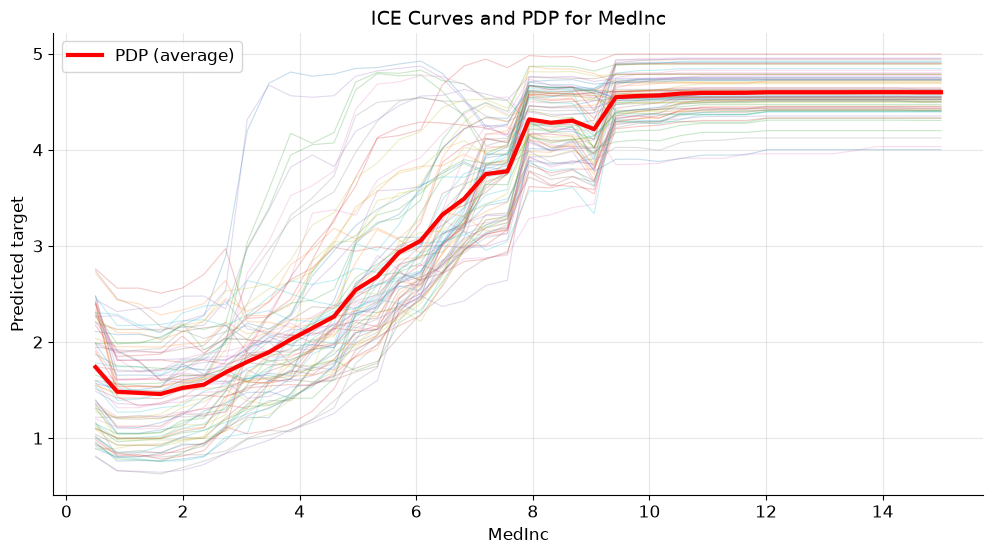

In [14]:
def plot_ice_curves(
    model, X, feature, n_instances=50, grid_resolution=50, random_state=42
):
    rng = np.random.RandomState(random_state)
    indices = rng.choice(len(X), size=min(n_instances, len(X)), replace=False)
    feature_values = np.linspace(X[feature].min(), X[feature].max(), grid_resolution)

    plt.figure(figsize=(12, 6))

    # ICE curves
    for idx in indices:
        ice_preds = []
        row = X.iloc[[idx]].copy()
        for val in feature_values:
            row_tmp = row.copy()
            row_tmp[feature] = val
            ice_preds.append(model.predict(row_tmp)[0])
        plt.plot(feature_values, ice_preds, alpha=0.25, linewidth=0.8)

    # PDP overlay
    pdp_vals = []
    for val in feature_values:
        X_tmp = X.copy()
        X_tmp[feature] = val
        pdp_vals.append(model.predict(X_tmp).mean())

    plt.plot(feature_values, pdp_vals, color="red", linewidth=3, label="PDP (average)")
    plt.xlabel(feature)
    plt.ylabel("Predicted target")
    plt.title(f"ICE Curves and PDP for {feature}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_ice_curves(model, X, "MedInc", n_instances=80, grid_resolution=40)

#### Expected Output (text)

```text
The plot shows:
- Many thin lines (ICE curves for individual houses)
- One thick line (PDP - average effect)
- Reveals heterogeneity in predictions
```


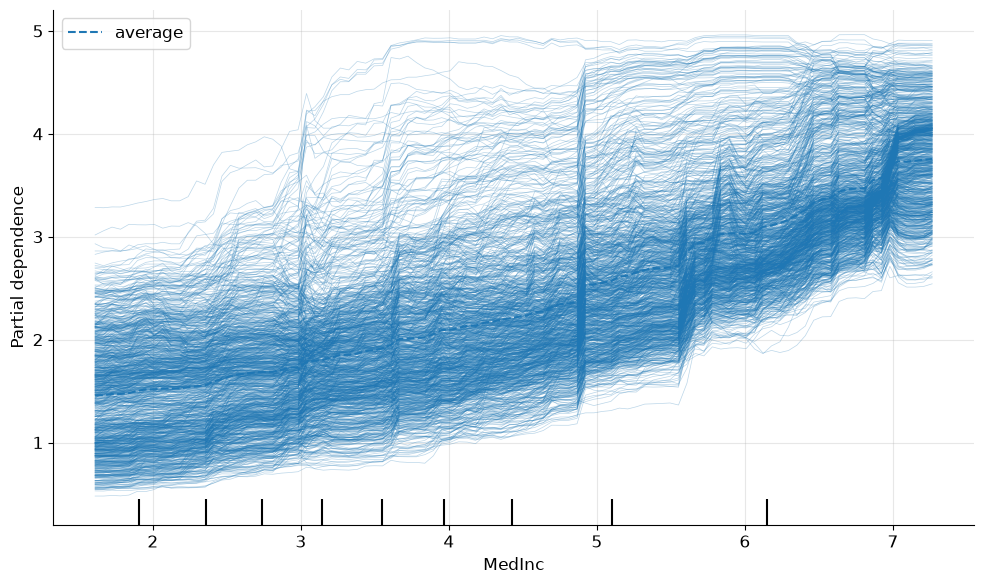

In [15]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    model,
    X,
    features=[feature_index(X, "MedInc")],
    kind="both",  # ICE + PDP
    ax=ax,
)
plt.tight_layout()
plt.show()

In [16]:
# ICE / Ceteris Paribus with DALEX (optional)
try:
    import dalex as dx
except ImportError:
    print("DALEX not installed. Install with: pip install dalex")
else:
    exp = dx.Explainer(model, X, y, label="Housing Model")
    observation = X.iloc[0]
    cp = exp.predict_profile(observation)
    print(cp)
    # cp.plot()  # optional plot

DALEX not installed. Install with: pip install dalex


#### Interpretation Examples (ICE)

**Heterogeneous Effects**

```text
Feature: Education Years
- Most curves increase monotonically
- Some curves are flat (education doesn't matter for some professions)
- A few curves decrease (measurement/data quality issues)
PDP hides this heterogeneity!
```

**Identifying Subgroups**

```text
Feature: House Age
ICE reveals two clusters:
1) Steep declining curves (older houses lose value)
2) Flat or increasing curves (vintage houses gain value)
Action: investigate what differentiates the groups (location, quality, style)
```


#### Advantages and Disadvantages (ICE)

**Advantages:**
- ✓ Reveals heterogeneity hidden by PDPs
- ✓ Can identify subgroups with different behaviors
- ✓ More complete picture of model behavior
- ✓ Easy to understand

**Disadvantages:**
- ✗ Same limitations as PDPs (correlation issues)
- ✗ Plots can become cluttered
- ✗ Harder to extract actionable insights than a single PDP line
- ✗ Computational cost for large datasets

```{tip}
Use ICE plots to **investigate unexpected PDP patterns**.
```


### Centered ICE (c-ICE)

Sometimes it's useful to center ICE curves to better see deviations from a baseline.


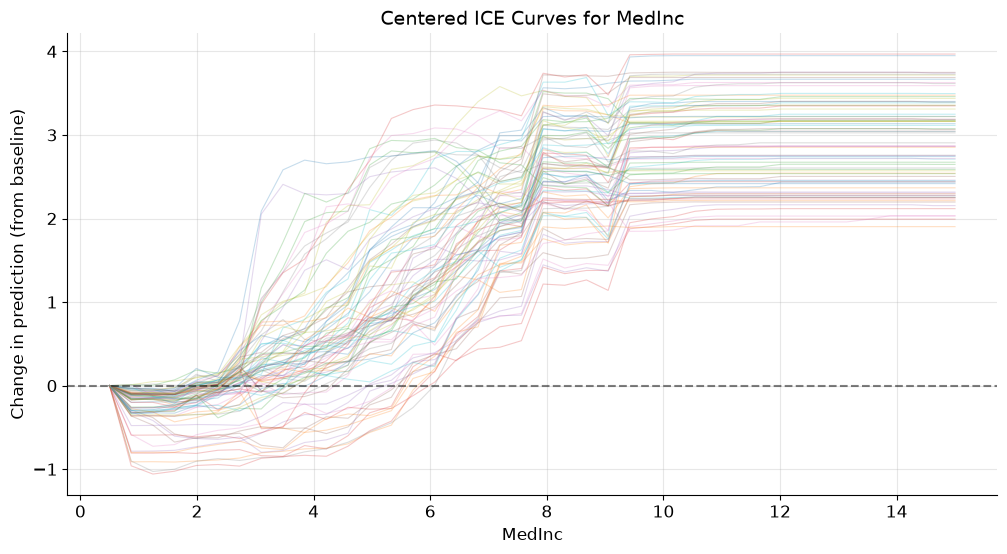

In [17]:
def plot_centered_ice(
    model, X, feature, n_instances=50, grid_resolution=50, random_state=42
):
    rng = np.random.RandomState(random_state)
    indices = rng.choice(len(X), size=min(n_instances, len(X)), replace=False)
    feature_values = np.linspace(X[feature].min(), X[feature].max(), grid_resolution)

    plt.figure(figsize=(12, 6))

    for idx in indices:
        preds = []
        row = X.iloc[[idx]].copy()
        for val in feature_values:
            row_tmp = row.copy()
            row_tmp[feature] = val
            preds.append(model.predict(row_tmp)[0])

        preds = np.array(preds)
        centered = preds - preds[0]
        plt.plot(feature_values, centered, alpha=0.25, linewidth=0.8)

    plt.axhline(0, color="black", linestyle="--", alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel("Change in prediction (from baseline)")
    plt.title(f"Centered ICE Curves for {feature}")
    plt.grid(True, alpha=0.3)
    plt.show()


plot_centered_ice(model, X, "MedInc", n_instances=80, grid_resolution=40)

### Shapley Values (SHAP)

We often face scenarios with high-dimensional models with many interactions, and the question is: **How much does each feature contribute to a specific prediction?**

**Simple Example: Linear Model**

$$
y = 0.5x_1 + 0.2x_2
$$

With interactions:

$$
y = 0.5x_1 + 0.2x_2 + 0.3x_1x_2
$$

SHAP {cite}`lundberg2017shap,lundberg2020treeshap` operationalises Shapley values for ML: it provides a **unique, theoretically grounded** way to attribute contributions to individual predictions.


#### Game Theory Foundation

The theory behind Shapley values in machine learning originates from **cooperative game theory** {cite}`shapley1953value`.

- Features are players
- Prediction is payout
- Goal: fairly distribute payout among players

**Shapley Value:** average marginal contribution across all coalitions.


#### The Shapley formula

For a coalitional game with player set $N = \{1, \dots, p\}$ and value function $v : 2^N \to \mathbb{R}$, the **Shapley value** of player $j$ is

$$
\phi_j \;=\; \sum_{S \,\subseteq\, N \setminus \{j\}}
\frac{|S|! \,(|N| - |S| - 1)!}{|N|!}
\bigl[\,v(S \cup \{j\}) \;-\; v(S)\,\bigr].
$$

The bracketed term is the **marginal contribution** of $j$ when added to coalition $S$; the combinatorial weight $|S|!(|N|-|S|-1)!/|N|!$ is the probability of encountering that coalition under a uniformly random ordering of players. So $\phi_j$ is the *average marginal contribution* over all orderings.

In an ML setting, players are features and $v(S)$ is (a conditional or interventional expectation of) the model's prediction when only features in $S$ are "known".

#### The four axioms

Shapley values are the **unique** allocation satisfying all four of:

1. **Efficiency (local accuracy).** Contributions sum to the difference from the baseline:
$$
\sum_{j=1}^{p} \phi_j \;=\; v(N) - v(\emptyset) \;=\; \hat{f}(x) - \mathbb{E}[\hat{f}(X)].
$$
2. **Symmetry.** If $v(S \cup \{i\}) = v(S \cup \{j\})$ for every $S \subseteq N \setminus \{i, j\}$, then $\phi_i = \phi_j$.
3. **Dummy.** If $v(S \cup \{j\}) = v(S)$ for every $S$, then $\phi_j = 0$.
4. **Additivity.** For any two games $v, w$ on the same $N$, $\phi_j(v + w) = \phi_j(v) + \phi_j(w)$.

Shapley (1953) {cite}`shapley1953value` proved that these four axioms characterise a *unique* allocation rule. {cite:t}`young1985monotonic` later gave a strictly stronger uniqueness result: replacing Additivity with a **strong monotonicity** axiom (if $j$'s marginal contributions weakly increase across all coalitions, then $\phi_j$ weakly increases) yields the same unique solution. This matters philosophically: Additivity is a linear-algebraic convenience, whereas monotonicity is a *behavioural* fairness property, so the Shapley value is fair in a game-theoretically robust sense.

:::{note}
These four axioms are precisely why SHAP is often described as "the unique fair attribution". Any attribution method violating even one of them can be shown to give demonstrably unfair credit on some game.
:::

In [18]:
# SHAP values for a linear model (optional: requires shap)
try:
    import shap
except ImportError:
    print("SHAP is not installed. Install with: pip install shap")
else:
    # Synthetic data
    np.random.seed(42)
    X_lin = pd.DataFrame(
        {
            "x1": np.random.randn(200),
            "x2": np.random.randn(200),
            "x3": np.random.randn(200),
        }
    )
    y_lin = 2 * X_lin["x1"] + 3 * X_lin["x2"] + np.random.randn(200) * 0.1

    lin_model = LinearRegression().fit(X_lin, y_lin)

    explainer = shap.LinearExplainer(lin_model, X_lin)
    shap_values = explainer.shap_values(X_lin)

    instance_idx = 0
    instance = X_lin.iloc[instance_idx]
    instance_shap = shap_values[instance_idx]

    pred = lin_model.predict(instance.to_frame().T)[0]
    base = explainer.expected_value

    print("Instance:", instance.values)
    print(f"Prediction: {pred:.4f}")
    print(f"Base value (average): {base:.4f}")
    print("\nFeature Contributions (SHAP values):")
    for feature, value, sval in zip(
        X_lin.columns, instance.values, instance_shap, strict=False
    ):
        print(f"  {feature:5s}: value={value:7.3f}, SHAP={sval:7.3f}")

    print("\nVerification:")
    print(f"  Base + sum(SHAP) = {base + instance_shap.sum():.4f}")
    print(f"  Prediction       = {pred:.4f}")

SHAP is not installed. Install with: pip install shap


#### Shapley Values for Complex Models

For non-linear models (trees, neural networks), we need approximations. Common options:

- **TreeSHAP**: efficient for tree models
- **KernelSHAP**: model-agnostic (slower)


#### Computational Complexity

Exact Shapley values require evaluating $2^p$ coalitions for $p$ features (exponential / NP-hard).

- **TreeSHAP** {cite}`lundberg2020treeshap`: exploits tree structure and runs in time **polynomial in the tree depth** ($O(TLD^2)$ for $T$ trees with $L$ leaves and depth $D$) rather than exponential in the number of features.
- **KernelSHAP** {cite}`lundberg2017shap`: model-agnostic, weighted-linear-regression approximation (slower, and only *approximate*).

#### Interventional vs observational (path-dependent) Shapley values

How you handle "absent" features when computing $v(S)$ is not a technicality — it changes what the resulting $\phi_j$ *means*. {cite:t}`janzing2020feature` formalise this as a **causal** problem: attribution is a question about interventions, not conditional distributions.

- The **observational** (or *conditional*, *path-dependent*) formulation defines
  $v(S) = \mathbb{E}\bigl[\hat{f}(X) \mid X_S = x_S\bigr]$,
  integrating over $P(X_{\bar S} \mid X_S = x_S)$. It respects the data manifold but attributes credit to features that are merely *correlated* with the true causal drivers — a "sink" feature that carries information from an upstream cause receives non-zero attribution even if the model does not use it.

- The **interventional** (or *marginal*) formulation defines
  $v(S) = \mathbb{E}\bigl[\hat{f}(x_S, X_{\bar S})\bigr]$,
  integrating over the marginal $P(X_{\bar S})$. This is the PDP-style marginalisation, breaks feature correlations by an implicit $\operatorname{do}(X_{\bar S})$ intervention, and matches `shap.TreeExplainer(..., feature_perturbation="interventional")`. It answers a genuinely causal question — *"how does the model use this feature, holding all else at its population distribution?"* — but can evaluate the model off-manifold.

{cite:t}`janzing2020feature` argue that most practical explainability questions ("which features does the model *use*?") are interventional in nature, and that using the conditional formulation smuggles in an unstated assumption that the training-data correlation structure is causally meaningful. Choose interventional for *"how the model uses this feature"*, conditional for *"how much information this feature carries in this dataset"*. The two can disagree substantially when features are correlated.

In [19]:
# KernelSHAP demo (optional; can be slow). Uses a tiny background for speed.
try:
    import shap
except ImportError:
    print("SHAP is not installed. Install with: pip install shap")
else:
    background = X_train.iloc[:50]
    sample = X_test.iloc[:5]

    # Use predict function for regression
    kernel_explainer = shap.KernelExplainer(model.predict, background)
    kernel_shap_vals = kernel_explainer.shap_values(sample, nsamples=200)

    print("KernelSHAP values shape:", np.array(kernel_shap_vals).shape)

SHAP is not installed. Install with: pip install shap


#### Practical SHAP Workflow (runnable template)

Below: a runnable workflow for RandomForestRegressor on housing. (Requires `shap`.)


In [20]:
# Practical SHAP workflow on housing RF (optional)
try:
    import shap
except ImportError:
    print("SHAP is not installed. Install with: pip install shap")
else:
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_test)

    shap.summary_plot(shap_vals, X_test, plot_type="bar")
    shap.summary_plot(shap_vals, X_test)

    instance_idx = 0
    exp = shap.Explanation(
        values=shap_vals[instance_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[instance_idx].values,
        feature_names=X_test.columns.tolist(),
    )
    shap.waterfall_plot(exp)

    shap.dependence_plot("MedInc", shap_vals, X_test)

SHAP is not installed. Install with: pip install shap


#### Advantages and Disadvantages (SHAP)

**Advantages:**
- ✓ Solid theoretical foundation
- ✓ Contrastive explanations (relative to average prediction)
- ✓ Works for any model (model-agnostic)
- ✓ Both local and global interpretations
- ✓ Excellent visualizations
- ✓ Handles feature interactions naturally

**Disadvantages:**
- ✗ Computationally expensive
- ✗ Requires choosing a background dataset (KernelSHAP)
- ✗ Can be slow for large datasets
- ✗ Interpretation can be tricky with correlated features
- ✗ Multiple implementations with slight differences

```{warning}
SHAP values can be **misleading with highly correlated features**. The Shapley value might attribute effects arbitrarily between correlated features. Always check feature correlations first!
```


#### When to Use SHAP
- ✓ Need theoretically grounded explanations
- ✓ Explaining individual predictions (local)
- ✓ Comparing feature importance across models
- ✓ High-stakes applications
- ✓ Tree-based models (TreeSHAP is very efficient)


## Explainable Boosting Machine (EBM)
### Introduction

While linear models offer great interpretability, they often have limitations:

- Must **manually** specify transformations and interactions
- Performance is often **worse than** GBMs or neural networks

**Idea:** Can we get the best of both worlds?

- Interpretability of linear models (additive structure)
- Performance of boosting (automatic feature engineering)

**Answer:** Yes! Explainable Boosting Machines (EBM)


### What is EBM?

EBM {cite}`nori2019interpretml` is a **Generalized Additive Model (GAM)** of the form:

$$
\mathbb{E}[y] = g^{-1}\left(\beta_0 + \sum_{j} f_j(x_j) + \sum_{j,k} f_{jk}(x_j, x_k)\right)
$$

where:

- $g^{-1}$: Link function (identity for regression, logit for classification)
- $f_j(x_j)$: Learned univariate shape function for feature $j$
- $f_{jk}(x_j, x_k)$: Learned pairwise interaction (optional)
- $\beta_0$: Intercept

**Key Innovation:** The shape functions $f_j$ are learned by **gradient boosting**, not specified manually!


### EBM vs Traditional GAM

**Traditional GAM** (e.g., with splines):

```python
from pygam import GAM, s

# Must specify smoothness manually
gam = GAM(s(0) + s(1) + s(2))
gam.fit(X, y)
```

**EBM** (learned automatically):

```python
from interpret.glassbox import ExplainableBoostingRegressor

# Automatically learns optimal shapes
ebm = ExplainableBoostingRegressor()
ebm.fit(X, y)
```


## Fairness
Interpretability tools are one leg of *responsible ML*; **algorithmic fairness** is the other. Once we can see how a model makes decisions, we still need a language to ask whether those decisions are equitable across subgroups.

### Group fairness definitions

Let $A \in \{0, 1\}$ be a binary **sensitive attribute** (e.g. gender, ethnicity), $Y \in \{0, 1\}$ the true label, and $\hat{Y} \in \{0, 1\}$ the model's prediction.

**Demographic parity (statistical parity).** Selection rates are equal across groups:

$$
\Pr(\hat{Y} = 1 \mid A = 0) = \Pr(\hat{Y} = 1 \mid A = 1).
$$

The **demographic parity difference** (DPD) is the LHS − RHS, and the **disparate impact ratio** is the ratio. A common rule of thumb (US "four-fifths rule") flags a ratio below 0.8.

**Equalised odds** {cite}`hardt2016equality`. True positive and false positive rates are equal across groups:

$$
\Pr(\hat{Y} = 1 \mid Y = y, A = 0) = \Pr(\hat{Y} = 1 \mid Y = y, A = 1) \quad \text{for } y \in \{0, 1\}.
$$

**Predictive parity / calibration.** Positive predictive value is equal across groups:

$$
\Pr(Y = 1 \mid \hat{Y} = 1, A = 0) = \Pr(Y = 1 \mid \hat{Y} = 1, A = 1).
$$

**Individual fairness** {cite}`dwork2012fairness`. Beyond group notions, individual fairness demands that *similar individuals be treated similarly* — formally, that the map $x \mapsto \hat{Y}(x)$ be Lipschitz-continuous with respect to a task-specific similarity metric. This shifts the ethical burden onto *defining what "similar" means*, which is often as contested as the fairness question itself.

### The incompatibility theorem

Whenever base rates differ across groups ($\Pr(Y=1 \mid A=0) \neq \Pr(Y=1 \mid A=1)$) and the classifier is not perfect, **you cannot simultaneously satisfy calibration and equalised odds** {cite}`chouldechova2017fair,kleinberg2017inherent`. This is a mathematical fact, not an engineering shortcoming — it forces a normative choice about *which* fairness criterion matters for a given application. The COMPAS recidivism debate is the canonical illustration: ProPublica critiqued the tool on false-positive-rate grounds; Northpointe defended it on calibration grounds; both were internally consistent.

:::{warning}
There is no single "fairness metric" you can optimise. Different definitions encode different ethical commitments and are provably in tension. Choose *before* modelling, and document the choice.
:::

### The EU AI Act and interpretability

The EU AI Act {cite}`euaiact2024` (in force 2024, phased application through 2026–2027) organises AI systems into risk tiers:

- **Unacceptable risk** — banned (e.g. social scoring, real-time biometric ID in public spaces with narrow exceptions).
- **High risk** — permitted subject to strict obligations. Includes AI in credit scoring, employment, education, essential public services, law enforcement, migration, and safety components of regulated products. Requires *risk management, data governance, technical documentation, human oversight, robustness, and — crucially — transparency and explainability*.
- **Limited risk** — transparency obligations (e.g. disclose AI-generated content, chatbot identity).
- **Minimal risk** — no obligations beyond existing law.

For high-risk systems, the tools in this lecture (PDP, ALE, SHAP, EBMs) and the fairness metrics above are not optional analytical niceties — they are how you evidence compliance with Articles 13 (transparency), 14 (human oversight) and 15 (accuracy, robustness).

### Minimal fairness example

We build a small binary classification proxy on California Housing (predict whether a district is "high value") with a **synthetic** sensitive attribute, then compute demographic parity by hand — falling back gracefully if `fairlearn` isn't installed.

:::{warning}
**Impossibility theorem of fairness.** Independently, {cite:t}`chouldechova2017fair` and {cite:t}`kleinberg2017inherent` proved that whenever base rates differ across groups —
$\Pr(Y=1 \mid A=0) \neq \Pr(Y=1 \mid A=1)$ — and the classifier is not a perfect oracle, **no scoring rule can simultaneously satisfy**:

1. **Calibration within groups** (predictive parity): $\Pr(Y=1 \mid \hat{s}, A) = \hat{s}$ for both groups.
2. **Equal false-positive rates** across groups.
3. **Equal false-negative rates** across groups.

This is a *mathematical impossibility*, not an engineering shortcoming. Any deployment must therefore make an **explicit, documented normative choice** about which criterion matters most for the application. The COMPAS debate is the canonical example: Northpointe's tool satisfied within-group calibration; ProPublica showed it violated equal FPR/FNR; both audits were internally correct — the trade-off is unavoidable when recidivism base rates differ across groups.
:::

### Counterfactual explanations

An orthogonal answer to the "why" question comes from **counterfactual explanations** {cite}`wachter2018counterfactual`: rather than decomposing a prediction into feature contributions, we ask *"what would have to change about this instance for the model to produce a different decision?"*

Formally, given a model $\hat{f}$, an instance $x$, and a desired outcome $y'$, a counterfactual $x'$ is a solution to

$$
x' \;=\; \arg\min_{x^\star} \; d(x, x^\star)
\quad \text{subject to} \quad \hat{f}(x^\star) = y',
$$

where $d$ is a distance (typically weighted $\ell_1$, favouring sparse changes across few features). {cite:t}`wachter2018counterfactual` propose relaxing the hard constraint into a Lagrangian penalty

$$
L(x^\star; \lambda) \;=\; \lambda \bigl(\hat{f}(x^\star) - y'\bigr)^2 + d(x, x^\star),
$$

and minimising over $x^\star$ with $\lambda$ increased until the outcome constraint is met.

**Why this matters.** Counterfactuals produce *actionable* explanations — "your loan would have been approved with £3,000 more annual income" — which map naturally onto the "meaningful information about the logic involved" that Article 22 of the GDPR requires for automated decisions. They are also **model-agnostic** and do not require access to model internals, making them attractive for third-party audits.

**Caveats:**

- Counterfactuals are not unique — many different $x'$ may all flip the decision. Diverse counterfactual generators (e.g. DiCE) report a *set* of counterfactuals.
- A counterfactual is only *plausible* if it lies in the data distribution; naive optimisation can produce infeasible instances (e.g. "reduce your age by 10 years").
- They explain individual *decisions*, not the *model* globally.

:::{note}
For a book-length treatment of every method in this lecture — PDP, ALE, ICE, permutation importance, SHAP, LIME, EBMs, counterfactuals, and their pitfalls — see {cite:t}`molnar2020interpretable`, which is freely available online and is the definitive reference for interpretable machine learning.
:::

In [ ]:
# Fairness metrics on a California Housing "high value" classifier
# with a synthetic sensitive attribute.
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Binary target: is the district in the top 30% of median house values?
threshold = y.quantile(0.7)
y_binary = (y >= threshold).astype(int)

# Synthetic sensitive attribute A, correlated with MedInc (to induce
# a base-rate difference — otherwise fairness metrics are uninteresting).
rng = np.random.RandomState(0)
prob_a1 = 1 / (1 + np.exp(-(X["MedInc"] - X["MedInc"].median())))
A = (rng.uniform(size=len(X)) < prob_a1).astype(int)
A = pd.Series(A, index=X.index, name="A")

X_tr, X_te, y_tr, y_te, A_tr, A_te = train_test_split(
    X, y_binary, A, test_size=0.3, random_state=42, stratify=y_binary
)

clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf.fit(X_tr, y_tr)
y_pred = clf.predict(X_te)


# --- Hand-computed group fairness metrics ---------------------------------
def selection_rate(y_hat, group_mask):
    return float(np.mean(y_hat[group_mask]))


def tpr_fpr(y_true, y_hat, group_mask):
    yt = np.asarray(y_true)[group_mask]
    yh = np.asarray(y_hat)[group_mask]
    tpr = np.mean(yh[yt == 1]) if (yt == 1).any() else np.nan
    fpr = np.mean(yh[yt == 0]) if (yt == 0).any() else np.nan
    return tpr, fpr


mask0 = A_te.values == 0
mask1 = A_te.values == 1

sr0 = selection_rate(y_pred, mask0)
sr1 = selection_rate(y_pred, mask1)
dpd = sr1 - sr0  # demographic parity difference
dir_ = sr1 / sr0 if sr0 > 0 else np.nan  # disparate impact ratio

tpr0, fpr0 = tpr_fpr(y_te.values, y_pred, mask0)
tpr1, fpr1 = tpr_fpr(y_te.values, y_pred, mask1)

print("Base rates (P(Y=1|A)):")
print(f"  A=0: {y_te.values[mask0].mean():.3f}")
print(f"  A=1: {y_te.values[mask1].mean():.3f}")
print()
print("Selection rates (P(Yhat=1|A)):")
print(f"  A=0: {sr0:.3f}")
print(f"  A=1: {sr1:.3f}")
print(f"Demographic parity difference: {dpd:+.3f}")
print(f"Disparate impact ratio       : {dir_:.3f}  (four-fifths rule flags < 0.8)")
print()
print("Equalised-odds components:")
print(f"  TPR  A=0: {tpr0:.3f}   A=1: {tpr1:.3f}   diff: {tpr1 - tpr0:+.3f}")
print(f"  FPR  A=0: {fpr0:.3f}   A=1: {fpr1:.3f}   diff: {fpr1 - fpr0:+.3f}")

# --- Optional: fairlearn ---------------------------------------------------
try:
    from fairlearn.metrics import (
        MetricFrame,
        demographic_parity_difference,
        equalized_odds_difference,
    )
    from fairlearn.metrics import (
        selection_rate as fl_selection_rate,
    )
    from sklearn.metrics import accuracy_score
except ImportError:
    print("\nfairlearn not installed (optional). Install with: pip install fairlearn")
else:
    mf = MetricFrame(
        metrics={"accuracy": accuracy_score, "selection_rate": fl_selection_rate},
        y_true=y_te,
        y_pred=y_pred,
        sensitive_features=A_te,
    )
    print("\nfairlearn MetricFrame (by group):")
    print(mf.by_group)
    print(
        f"\nfairlearn demographic_parity_difference: "
        f"{demographic_parity_difference(y_te, y_pred, sensitive_features=A_te):+.3f}"
    )
    print(
        f"fairlearn equalized_odds_difference    : "
        f"{equalized_odds_difference(y_te, y_pred, sensitive_features=A_te):+.3f}"
    )

## Exercises
:::{admonition} Exercise 1 — PDP vs ALE for a correlated feature pair
:class: tip
Using the California Housing data, pick a correlated feature pair (e.g. `AveRooms` and `AveBedrms`, or `MedInc` and `AveRooms`). For each feature in the pair:

1. Compute a 1D **PDP** using `sklearn.inspection.PartialDependenceDisplay.from_estimator` (or your own implementation).
2. Compute a 1D **ALE** using the `compute_ale_1d` helper defined earlier in the notebook.
3. Overlay the two on the same axes and describe qualitatively where they diverge.
4. Compute the empirical Pearson correlation of the pair. Explain, referring to $P(X_C \mid X_S)$ vs $P(X_C)$, why the two curves diverge more strongly where the density of realistic $(x_S, x_C)$ combinations is thin.
:::

:::{admonition} Exercise 2 — Kernel SHAP by hand (then by library)
:class: tip
Kernel SHAP {cite}`lundberg2017shap` estimates Shapley values by fitting a weighted linear regression on coalition indicators. Implement it conceptually for a small tabular model:

1. Fit a `RandomForestRegressor` on California Housing (as in the notebook).
2. Pick one test instance $x^*$ and a background sample of 50 rows.
3. Enumerate a subset of feature coalitions $S \subseteq \{1, \dots, p\}$ (all subsets is $2^8 = 256$ — enumerate them exhaustively).
4. For each $S$, produce a "masked" prediction by replacing features not in $S$ with the background mean, and compute the Shapley kernel weight $\pi(S) = \frac{p - 1}{\binom{p}{|S|} \, |S| \, (p - |S|)}$.
5. Fit a weighted linear regression of masked prediction on the coalition indicators to obtain $\phi$.
6. Compare your $\phi$ vector to `shap.KernelExplainer` (if available). Comment on efficiency: local accuracy should give $\sum_j \phi_j \approx \hat{f}(x^*) - \mathbb{E}[\hat{f}]$.
:::

:::{admonition} Exercise 3 — Demographic parity on synthetic income data
:class: tip
Generate a synthetic classification problem where the true label $Y$ depends on a legitimate feature $Z$ (say, years of experience), but the sensitive attribute $A$ (say, gender) is *correlated* with $Z$:

1. Draw $A \sim \text{Bernoulli}(0.5)$, $Z \mid A \sim \mathcal{N}(\mu_A, 1)$ with $\mu_0 = -0.5, \mu_1 = 0.5$, $n = 5000$.
2. Set $Y = \mathbb{1}[Z + \varepsilon > 0]$ with $\varepsilon \sim \mathcal{N}(0, 0.5)$.
3. Train a logistic regression on $Z$ alone (no $A$). Compute the **demographic parity difference** and the **disparate impact ratio** across values of $A$.
4. Now train a second logistic regression that includes $A$ as a feature. Do the fairness metrics improve, stay the same, or worsen? Why?
5. Discuss: given the incompatibility theorem {cite}`chouldechova2017fair,kleinberg2017inherent`, which fairness criterion would you argue for in a hiring context, and what does the EU AI Act {cite}`euaiact2024` require you to document?
:::

:::{admonition} Key Takeaways
:class: important
- Model evaluation must go beyond a single metric — consider the full error distribution and multiple perspectives (bias, calibration, ranking).
- Interpretability is not optional in high-stakes applications (finance, healthcare, policy) and is increasingly a **regulatory** requirement (EU AI Act {cite}`euaiact2024`, GDPR "right to explanation").
- Choose the right method for the question: **global vs local**, **model-specific vs model-agnostic**, **intrinsic vs post-hoc**.
- **PDPs** {cite}`friedman2001greedy` are simple but biased under feature correlation; **ALE** {cite}`apley2020ale` corrects for this by accumulating local effects.
- **SHAP** {cite}`lundberg2017shap,lundberg2020treeshap` provides theoretically grounded additive attributions rooted in Shapley (1953) cooperative game theory {cite}`shapley1953value`.
- **ICE curves** {cite}`goldstein2015ice` and **H²** {cite}`friedman2008predictive` reveal heterogeneity and interactions that averages hide.
- **Explainable Boosting Machines** {cite}`nori2019interpretml` offer glass-box accuracy competitive with black-box models.
- Interpretability tools are complementary: use several and cross-validate the story they tell.
- Post-deployment monitoring for **data drift** is covered in [Lecture 9](lecture_9.ipynb).
:::